### Setup

In [19]:
# Library
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import torch
import random
import numpy as np
from datetime import datetime
import json
from datasets import Dataset, DatasetDict
from tqdm import tqdm
from PIL import Image
from IPython.display import display
import torch
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from huggingface_hub import login
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, StableDiffusionPipeline
from diffusers.optimization import get_scheduler
from diffusers.utils import convert_state_dict_to_diffusers
from diffusers.training_utils import cast_training_params
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict

# GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device : ',device)   

# CONFIG
device = 'cuda' if torch.cuda.is_available() else 'cpu'
CURRENT_TIME = datetime.now().strftime("%Y%m%d_%H%M%S")
MASTER_SEED = 42

# TRAIN PARAMETER
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
EPOCHS = 200
LEARNING_RATE = 1e-04
TRAIN_DATA_SIZE = 1800
TEST_DATA_SIZE = 200

# PATH
CONFIG_PATH = '../config.json'
with open(CONFIG_PATH,'r') as f:
    config = json.load(f)
## DATA
TRAIN_IMAGE_FOLDER = config.get("TRAIN_IMAGE_FOLDER")
TRAIN_LABEL_FOLDER = config.get("TRAIN_LABEL_FOLDER")
TRAIN_IMAGE_FILE = sorted([f for f in os.listdir(TRAIN_IMAGE_FOLDER) if f.endswith('.jpg')], key=lambda x: int(x.split('.')[0]))
TRAIN_LABEL_FILE = sorted([f for f in os.listdir(TRAIN_LABEL_FOLDER) if f.endswith('.json')], key=lambda x: int(x.split('.')[0]))

## MODEL
PRE_TRAINED_MODEL_NAME="stablediffusionapi/deliberate-v2"
SAVE_MODEL_PATH = f"../Experiment/model/FIGMA_{CURRENT_TIME}"
SAVE_WEIGHTS_PATH = f"../Experiment/model_weights/FIGMA_weights_{CURRENT_TIME}"

## HUGGINGFACE
HUGGING_FACE_TOKEN = config.get("HUGGING_FACE_TOKEN")
login(HUGGING_FACE_TOKEN)

device :  cuda


### Load Model

In [3]:
noise_scheduler = DDPMScheduler.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="scheduler"
)
tokenizer = CLIPTokenizer.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="tokenizer"
)
text_encoder = CLIPTextModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="text_encoder"
)
vae = AutoencoderKL.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="vae"
)
unet = UNet2DConditionModel.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    subfolder="unet"
)
# Maximum token length input to the model
tokenizer.model_max_length

77

### Preprocess Data

In [4]:
# Function that tokenize a text column from a given data sample and returns a token ID tensor.
def tokenize_captions(examples, caption_column='text', is_train=True):
    captions = []
    for caption in examples[caption_column]:
        # 캡션이 하나인 경우
        if isinstance(caption, str):
            captions.append(caption)
        # 캡션이 하나 이상인 경우 아무거나 하나 선택
        elif isinstance(caption, (list, np.ndarray)):
            # take a random caption if there are multiple
            captions.append(random.choice(caption) if is_train else caption[0])
        else:
            raise ValueError(
                f"Caption column `{caption_column}` should contain either strings or lists of strings."
            )
    inputs = tokenizer(
        captions, max_length=tokenizer.model_max_length, padding="max_length", truncation=True, return_tensors="pt"
    )

    return inputs.input_ids

# Transformation pipeline to preprocess image data for training
transforms = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMG_SIZE) if True else transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip() if True else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]), # (0,1)->(-1,1)
    ]
)

# A function that converts image data to RGB, preprocesses it, and tokenize the text column to construct a training dataset
def preprocess_data(examples, image_column='image'):
    images = [image.convert("RGB") for image in examples[image_column]]
    # 이미지 전처리
    examples["pixel_values"] = [transforms(image) for image in images]
    # 텍스트 전처리
    examples["input_ids"] = tokenize_captions(examples)
    return examples

# A function that stacks images and token IDs in batches and converts them into PyTorch tensor forms
def collate_fn(examples):
    # (C, H, W), ..., (C, H, W) -> stack -> (N, C, H, W): N으로 스택
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    # tensor.contiguous()와 동일
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    # {(77,), ..., (77,)}_N개 -> stack -> (N, 77)
    input_ids = torch.stack([example["input_ids"] for example in examples])

    return {"pixel_values": pixel_values, "input_ids": input_ids}


- Train Data

In [5]:
data = []
for image_file, label_file in zip(TRAIN_IMAGE_FILE, TRAIN_LABEL_FILE):
    image_path = os.path.join(TRAIN_IMAGE_FOLDER, image_file)
    label_path = os.path.join(TRAIN_LABEL_FOLDER, label_file)
    # Open image file
    with open(image_path, 'rb') as image:
        image_data = Image.open(image)
        image_data = image_data.convert('RGB') 
    # Open label file
    with open(label_path, 'r') as label:
        label_data = json.load(label)  
    data.append({
        'image':image_data,
        'text':label_data
    })
    
# Convert to Dataset
dataset = Dataset.from_dict({
    'image': [item['image'] for item in data],
    'text': [item['text']['summary'] for item in data]
})

# Generate Train DatasetDict
train_dataset = DatasetDict({'train': dataset})

# Generate Train Data Loader
train_dataset = train_dataset.with_transform(preprocess_data)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(train_dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 1800
    })
})


- Checking Data 

In [9]:
train_dataloader_iter = iter(train_dataloader)
mini_batch = next(train_dataloader_iter)
print('Image Data : ', mini_batch['pixel_values'].shape)
print('Caption Data : ', mini_batch['input_ids'].shape)

Image Data :  torch.Size([4, 3, 512, 512])
Caption Data :  torch.Size([4, 77])


### Train Setting

In [9]:
# Setting FP16 for AMP application
weight_dtype = torch.float16 
# The unet, vae, and text encoder are not trained during fine-tuning
unet.requires_grad_(False)
vae.requires_grad_(False)
text_encoder.requires_grad_(False);

# LoRA Adapter 준비
LORA_RANK = 4
# Freeze the unet parameters before adding adapters
for param in unet.parameters():
    param.requires_grad_(False)
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)
# Move models to GPU
text_encoder.to(device);
vae.to(device);
unet.to(device);
unet.add_adapter(unet_lora_config)

# Cast the trainable parameters to float32
if weight_dtype == torch.float16:
    # only upcast trainable parameters (LoRA) into fp32
    cast_training_params(unet, dtype=torch.float32)

lora_layers = filter(lambda p: p.requires_grad, unet.parameters())

# Set Optimizer
optimizer = torch.optim.AdamW(
        lora_layers,
        lr=LEARNING_RATE,
    )
# Set Scheduler
lr_scheduler = get_scheduler(
        'linear',
        optimizer=optimizer,
        num_warmup_steps=500,
        num_training_steps=EPOCHS * len(train_dataloader)
    )

### Train Loop

In [ ]:
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
prediction_type = None  
train_losses = []

for epoch in range(EPOCHS):
    unet.train()
    text_encoder.train()
    vae.train()
    
    for step, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
        with torch.autocast(device_type=device, dtype=weight_dtype, enabled=use_amp):
            # latent encoding
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * vae.config.scaling_factor
            
            # Add noise and generate timestep
            noise = torch.randn_like(latents)
            bsz = latents.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            
            # Extract Text Embedding
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]
            if prediction_type is not None:
                noise_scheduler.register_to_config(prediction_type=prediction_type)
            if noise_scheduler.config.prediction_type == "epsilon":
                target = noise
            elif noise_scheduler.config.prediction_type == "v_prediction":
                target = noise_scheduler.get_velocity(latents, noise, timesteps)
            else:
                raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")
            
            # Calculate loss after noise prediction with UNet
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")
        
        train_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()
        optimizer.zero_grad()
    
    avg_train_loss = sum(train_losses[-100:]) / 100
    print(f'Finished epoch {epoch+1}. Average training loss (last 100): {avg_train_loss:05f}')


### Construct Pipeline

In [7]:
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.to(device);

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/home/gayeon38/anaconda3/envs/vlm-env/lib/python3.8/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


### Save Fine-Tuned Model

In [15]:
# Save model 
pipeline.save_pretrained(SAVE_MODEL_PATH)
# Save model weights
unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
StableDiffusionPipeline.save_lora_weights(
    save_directory=SAVE_WEIGHTS_PATH,
    unet_lora_layers=unet_lora_state_dict,
    safe_serialization=True,
)

### Load Fine-Tuning Model
- During LoRA Fine-Tuning, only LoRA parameters added to the base model (UNet of Stable diffusion) are updated, and the original weight of the base model is stored X
- Saved pipelines contain only UNet's default weight X, LoRA delta
- Apply Fine-tuned LoRA weights after loading the base model separately

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

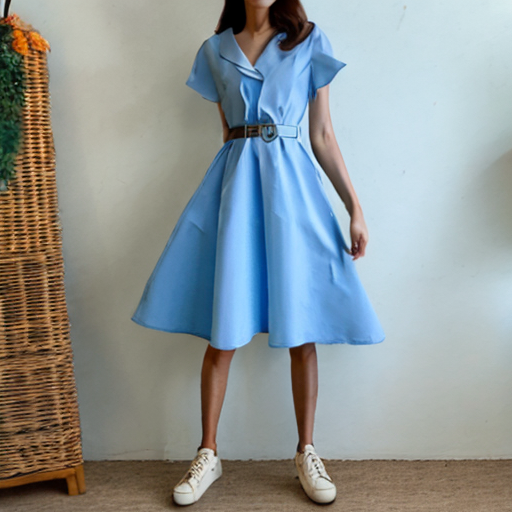

In [16]:
# Load Saved Model
pipe = StableDiffusionPipeline.from_pretrained(PRE_TRAINED_MODEL_NAME, torch_dtype=torch.float16)
pipe.to("cuda")
pipe.load_lora_weights(SAVE_WEIGHTS_PATH, safe_serialization=True)

# Create an image based on prompt
prompt = "a sky blue dress with a brown belt and a white shoes"
generated_image = pipe(prompt).images[0]
generated_image